In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train = pd.read_csv('/content/drive/MyDrive/Colab/train.csv', parse_dates=['Date'])
store = pd.read_csv('/content/drive/MyDrive/Colab/store.csv')



/tmp/ipykernel_5327/1604187504.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/content/drive/MyDrive/Colab/train.csv', parse_dates=['Date'])


In [4]:
data = pd.merge(train, store, how='left', on='Store')
data.isnull().sum()




,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [5]:
data['CompetitionDistance'].fillna(data['CompetitionDistance'].median(), inplace=True)
data['CompetitionOpenSinceMonth'].fillna(0, inplace=True)
data['CompetitionOpenSinceYear'].fillna(0, inplace=True)
data['Promo2SinceWeek'].fillna(0, inplace=True)
data['Promo2SinceYear'].fillna(0, inplace=True)
data['PromoInterval'].fillna('0', inplace=True)

display(data.isnull().sum())

/tmp/ipykernel_5327/3380060076.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['CompetitionDistance'].fillna(data['CompetitionDistance'].median(), inplace=True)
/tmp/ipykernel_5327/3380060076.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [6]:
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [7]:
data['StateHoliday'].replace('0',0)
data['SchoolHoliday'].astype(int)
data = data[data['Open'] == 1]



In [8]:
#extracting further details from the date column
data['Year'] = data['Date'].dt.year
data['Month'] = data['Date'].dt.month
data['Day'] = data['Date'].dt.day
data['WeekOfYear'] = data['Date'].dt.isocalendar().week.astype(int)
data['DayOfWeek'] = data['Date'].dt.dayofweek



In [9]:
data.shape[0]

844392

In [10]:
mask = (data['CompetitionOpenSinceYear'] > 0) & (data['CompetitionOpenSinceMonth'] > 0)
data.loc[mask, 'CompetitionOpenSinceDate'] = pd.to_datetime(
    dict(
        year=data.loc[mask, 'CompetitionOpenSinceYear'].astype(int),
        month=data.loc[mask, 'CompetitionOpenSinceMonth'].astype(int),
        day=1
    )
)






In [11]:

# Identify rows where CompetitionOpenSinceDate is valid
valid_competition_dates_mask = data['CompetitionOpenSinceDate'].notna()  # will return a true/false series if date is present

# Calculate CompetitionOpenMonths for valid dates
data.loc[valid_competition_dates_mask, 'CompetitionOpenMonths'] = (
    (data.loc[valid_competition_dates_mask, 'Date'].dt.year - data.loc[valid_competition_dates_mask, 'CompetitionOpenSinceDate'].dt.year) * 12
    + (data.loc[valid_competition_dates_mask, 'Date'].dt.month - data.loc[valid_competition_dates_mask, 'CompetitionOpenSinceDate'].dt.month)
)

# Fill any remaining NaN values (where CompetitionOpenSinceDate was not valid) with 0
data['CompetitionOpenMonths'].fillna(0, inplace=True)
data['CompetitionOpenMonths']
data.head()

/tmp/ipykernel_5327/1989519429.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['CompetitionOpenMonths'].fillna(0, inplace=True)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear,CompetitionOpenSinceDate,CompetitionOpenMonths
0,1,4,2015-07-31,5263,555,1,1,0,1,c,...,0,0.0,0.0,0,2015,7,31,31,2008-09-01,82.0
1,2,4,2015-07-31,6064,625,1,1,0,1,a,...,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31,31,2007-11-01,92.0
2,3,4,2015-07-31,8314,821,1,1,0,1,a,...,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31,31,2006-12-01,103.0
3,4,4,2015-07-31,13995,1498,1,1,0,1,c,...,0,0.0,0.0,0,2015,7,31,31,2009-09-01,70.0
4,5,4,2015-07-31,4822,559,1,1,0,1,a,...,0,0.0,0.0,0,2015,7,31,31,2015-04-01,3.0


In [12]:
data = pd.get_dummies(
    data,
    columns=['StoreType', 'Assortment', 'PromoInterval'],
    drop_first=True
)



In [13]:
data.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,...,CompetitionOpenSinceDate,CompetitionOpenMonths,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
0,1,4,2015-07-31,5263,555,1,1,0,1,1270.0,...,2008-09-01,82.0,False,True,False,False,False,False,False,False
1,2,4,2015-07-31,6064,625,1,1,0,1,570.0,...,2007-11-01,92.0,False,False,False,False,False,False,True,False
2,3,4,2015-07-31,8314,821,1,1,0,1,14130.0,...,2006-12-01,103.0,False,False,False,False,False,False,True,False
3,4,4,2015-07-31,13995,1498,1,1,0,1,620.0,...,2009-09-01,70.0,False,True,False,False,True,False,False,False
4,5,4,2015-07-31,4822,559,1,1,0,1,29910.0,...,2015-04-01,3.0,False,False,False,False,False,False,False,False


In [14]:
data.drop(['Date'], axis=1, inplace=True)


In [15]:
data.drop([
    'CompetitionOpenSinceYear',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceDate'   # ← YES, this one is no longer needed
], axis=1, inplace=True)


In [16]:
data.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,CompetitionDistance,Promo2,...,WeekOfYear,CompetitionOpenMonths,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,"PromoInterval_Feb,May,Aug,Nov","PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec"
0,1,4,5263,555,1,1,0,1,1270.0,0,...,31,82.0,False,True,False,False,False,False,False,False
1,2,4,6064,625,1,1,0,1,570.0,1,...,31,92.0,False,False,False,False,False,False,True,False
2,3,4,8314,821,1,1,0,1,14130.0,1,...,31,103.0,False,False,False,False,False,False,True,False
3,4,4,13995,1498,1,1,0,1,620.0,0,...,31,70.0,False,True,False,False,True,False,False,False
4,5,4,4822,559,1,1,0,1,29910.0,0,...,31,3.0,False,False,False,False,False,False,False,False


In [17]:
print(data.isnull().sum().sum())
data.dtypes


0


,0
Store,int64
DayOfWeek,int32
Sales,int64
Customers,int64
Open,int64
Promo,int64
StateHoliday,object
SchoolHoliday,int64
CompetitionDistance,float64
Promo2,int64


In [18]:
data = pd.get_dummies(data, columns=['StateHoliday'], drop_first=True)


In [19]:
data.dtypes

,0
Store,int64
DayOfWeek,int32
Sales,int64
Customers,int64
Open,int64
Promo,int64
SchoolHoliday,int64
CompetitionDistance,float64
Promo2,int64
Promo2SinceWeek,float64


In [20]:
# Saving processed dataset in Drive
data.to_csv('/content/drive/MyDrive/Colab/rossmann_processed.csv', index=False)



In [21]:
print(data['Sales'].describe())


count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


In [22]:
data = pd.read_csv('/content/drive/MyDrive/Colab/rossmann_processed.csv')

X = data.drop(['Sales'], axis=1)
y = data['Sales']


In [23]:
train_df = data[data['Year'] < 2015]
valid_df = data[data['Year'] == 2015]

X_train = train_df.drop(['Sales'], axis=1)
y_train = train_df['Sales']

X_valid = valid_df.drop(['Sales'], axis=1)
y_valid = valid_df['Sales']


In [24]:
!pip install xgboost
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.2 MB/s eta 0:00:00


In [25]:
import numpy as np

y_train_log = np.log1p(y_train)
y_valid_log = np.log1p(y_valid)

model = XGBRegressor(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train_log)

preds_log = model.predict(X_valid)
preds = np.expm1(preds_log)   # convert back
rmse = np.sqrt(mean_squared_error(y_valid, preds))

In [26]:
rmse

np.float64(595.0582692056299)

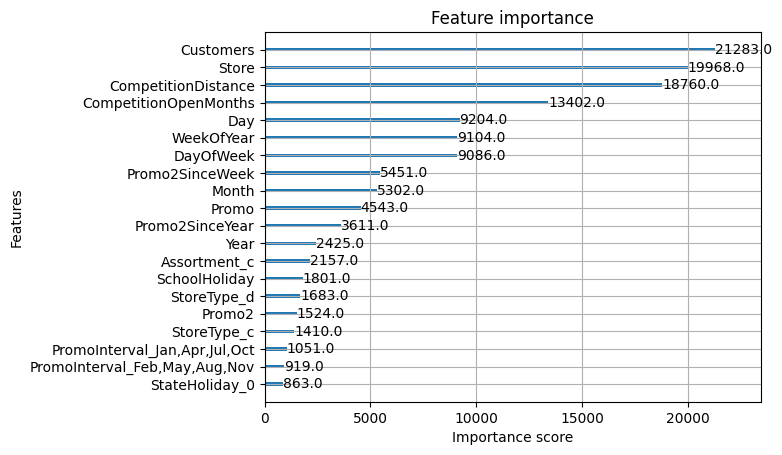

In [27]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=20)
plt.show()


In [28]:
X_train.shape

(648360, 27)

In [29]:
from sklearn.metrics import r2_score
print("R²:", r2_score(y_valid, preds))


R²: 0.9615388512611389


In [30]:
test_data = {
    'Store': 1,
    'DayOfWeek': 4,
    'Customers': 1000,
    'Open': 1,
    'Promo': 1,
    'SchoolHoliday': 1,
    'CompetitionDistance': 1000,
    'Promo2': 0,
    'Promo2SinceWeek': 0.0,
    'Promo2SinceYear': 0.0,
    'Year': 2014,
    'Month': 12,
    'Day': 25,
    'WeekOfYear': 47,
    'CompetitionOpenMonths': 100.0,
    'StoreType_b': 0,
    'StoreType_c': 1,
    'StoreType_d': 0,
    'Assortment_b': 0,
    'Assortment_c': 0,
    'PromoInterval_Feb,May,Aug,Nov': 0,
    'PromoInterval_Jan,Apr,Jul,Oct': 0,
    'PromoInterval_Mar,Jun,Sept,Dec': 0,
    'StateHoliday_0': 1,
    'StateHoliday_a': 0,
    'StateHoliday_b': 0,
    'StateHoliday_c': 0
}

test = pd.DataFrame([test_data])
predict_log = model.predict(test)
predict = np.expm1(predict_log)
predict

array([7913.327], dtype=float32)